# PCA - 17 macro-variables

- Goal: reduce dimensions of macro variables while retaining 
- Recall we want to avoid multicollinearity issues. Also aim to prevent redundancy.


In [8]:
#Using notebook 2

# --- Cell 1: imports and setup ---
import os
import numpy as np
import pandas as pd
from fredapi import Fred
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

load_dotenv()
fred = Fred(api_key=os.getenv('FRED_API_KEY'))

# --- Cell 2: helper functions ---

def get_series(ticker, name, filepath):
    if os.path.exists(filepath):
        data = pd.read_csv(filepath, index_col=0, parse_dates=True).squeeze()
        data.name = name
    else:
        data = fred.get_series(ticker)
        data.index = pd.to_datetime(data.index)
        data.name = name
        data.to_csv(filepath, header=True)

    n_missing = data.isna().sum()
    print(f"{name}: {n_missing} missing values")
    if n_missing > 0:
        print(data[data.isna()])

    data = data.ffill().dropna()
    return data


def resample_to_monthly(series, method='mean'):
    if method == 'mean':
        return series.resample('ME').mean()
    elif method == 'last':
        return series.resample('ME').last()
    elif method == 'max':
        return series.resample('ME').max()
    elif method == 'min':
        return series.resample('ME').min()
    else:
        raise ValueError("method must be 'mean', 'last', 'max', or 'min'")


def adf_report(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    stationary = result[1] < 0.05
    print(f"{name:30s} ADF={result[0]:8.4f}  p-value={result[1]:.4f}  stationary={'YES' if stationary else 'NO'}")
    return stationary, result[0], result[1]

# --- Cell 3: pull + resample all 17 series (no plots, no volatility — not needed for PCA) ---

series_config = {
    'CCSA':      {'name': 'continued_claims', 'method': 'mean'},
    'ICSA':      {'name': 'initial_claims',   'method': 'mean'},
    'BAA10Y':    {'name': 'baa10y_spread',    'method': 'last'},
    'NFCI':      {'name': 'nfci',             'method': 'last'},
    'T10Y2Y':    {'name': 't10y2y',           'method': 'last'},
    'CPIAUCSL':  {'name': 'cpi',              'method': 'mean'},
    'INDPRO':    {'name': 'indpro',           'method': 'mean'},
    'TB3MS':     {'name': 'tb3ms',            'method': 'mean'},
    'DCOILWTICO':{'name': 'wti',              'method': 'mean'},
    'TCU':       {'name': 'tcu',              'method': 'mean'},
    'UNRATE':    {'name': 'unrate',           'method': 'mean'},
    'UMCSENT':   {'name': 'umcsent',          'method': 'mean'},
    'BUSLOANS':  {'name': 'busloans',         'method': 'mean'},
    'CUMFNS':    {'name': 'cumfns',           'method': 'mean'},
    'M2SL':      {'name': 'm2',               'method': 'mean'},
    'PAYEMS':    {'name': 'payems',           'method': 'mean'},
    'PPIACO':    {'name': 'ppiaco',           'method': 'mean'},
}

monthly_series = {}

for ticker, cfg in series_config.items():
    name = cfg['name']
    filepath = f"../data/{name}.csv"
    raw = get_series(ticker, name, filepath)
    monthly = resample_to_monthly(raw, method=cfg['method'])
    monthly.name = f"{name}_monthly"
    monthly_series[ticker] = monthly

    # --- Cell 4: apply confirmed transforms (level / diff / log_diff) ---

transform_config = {
    'CCSA':       {'kind': 'level',    'ensae_name': 'Continued_claims'},
    'ICSA':       {'kind': 'level',    'ensae_name': 'Initial_claims'},
    'BAA10Y':     {'kind': 'level',    'ensae_name': 'Credit_spread'},
    'NFCI':       {'kind': 'level',    'ensae_name': 'NFCI'},
    'T10Y2Y':     {'kind': 'level',    'ensae_name': 'Slope'},
    'CUMFNS':     {'kind': 'level',    'ensae_name': 'CUMFNS'},
    'CPIAUCSL':   {'kind': 'log_diff', 'ensae_name': 'Log_CPI_diff'},
    'INDPRO':     {'kind': 'log_diff', 'ensae_name': 'Log_INDPRO_diff'},
    'TB3MS':      {'kind': 'diff',     'ensae_name': 'TB3MS_diff'},
    'DCOILWTICO': {'kind': 'log_diff', 'ensae_name': 'WTI_Returns'},
    'TCU':        {'kind': 'diff',     'ensae_name': 'TCU_diff'},
    'UNRATE':     {'kind': 'diff',     'ensae_name': 'UNRATE_diff'},
    'UMCSENT':    {'kind': 'diff',     'ensae_name': 'UMCSENT_diff'},
    'BUSLOANS':   {'kind': 'log_diff', 'ensae_name': 'Log_BUSLOANS_diff'},
    'M2SL':       {'kind': 'log_diff', 'ensae_name': 'Log_M2SL_diff'},
    'PAYEMS':     {'kind': 'log_diff', 'ensae_name': 'Log_PAYEMS_diff'},
    'PPIACO':     {'kind': 'log_diff', 'ensae_name': 'Log_PPIACO_diff'},
}


def apply_transform(series, kind):
    if kind == 'log_diff':
        return np.log(series).diff()
    elif kind == 'diff':
        return series.diff()
    elif kind == 'level':
        return series.copy()
    else:
        raise ValueError("kind must be 'log_diff', 'diff', or 'level'")


transformed_series = {}
for ticker, cfg in transform_config.items():
    monthly = monthly_series[ticker]
    transformed = apply_transform(monthly, cfg['kind'])
    transformed.name = cfg['ensae_name']
    transformed_series[ticker] = transformed

stationary_df = pd.concat(transformed_series.values(), axis=1, sort=False)
stationary_df = stationary_df.dropna()

print(stationary_df.shape)
stationary_df.head()

# --- Cell 5: correlation matrix — input to PCA ---

corr_matrix = stationary_df.corr()
corr_matrix.round(3)

continued_claims: 0 missing values
initial_claims: 0 missing values
baa10y_spread: 440 missing values
1986-01-20   NaN
1986-02-17   NaN
1986-03-28   NaN
1986-05-26   NaN
1986-07-04   NaN
              ..
2026-01-01   NaN
2026-01-19   NaN
2026-02-16   NaN
2026-04-03   NaN
2026-05-25   NaN
Name: baa10y_spread, Length: 440, dtype: float64
nfci: 0 missing values
t10y2y: 549 missing values
1976-07-05   NaN
1976-09-06   NaN
1976-10-11   NaN
1976-11-02   NaN
1976-11-11   NaN
              ..
2025-12-25   NaN
2026-01-01   NaN
2026-01-19   NaN
2026-02-16   NaN
2026-05-25   NaN
Name: t10y2y, Length: 549, dtype: float64
cpi: 1 missing values
2025-10-01   NaN
Name: cpi, dtype: float64
indpro: 0 missing values
tb3ms: 0 missing values
wti: 371 missing values
1986-02-17   NaN
1986-03-28   NaN
1986-05-26   NaN
1986-07-04   NaN
1986-09-01   NaN
              ..
2026-01-01   NaN
2026-01-19   NaN
2026-02-16   NaN
2026-04-03   NaN
2026-05-25   NaN
Name: wti, Length: 371, dtype: float64
tcu: 0 missing valu

,Continued_claims,Initial_claims,Credit_spread,NFCI,Slope,CUMFNS,Log_CPI_diff,Log_INDPRO_diff,TB3MS_diff,WTI_Returns,TCU_diff,UNRATE_diff,UMCSENT_diff,Log_BUSLOANS_diff,Log_M2SL_diff,Log_PAYEMS_diff,Log_PPIACO_diff
Continued_claims,1.000,0.777,0.353,0.107,0.297,-0.500,-0.112,-0.043,-0.103,0.091,0.006,0.129,-0.022,-0.074,0.492,-0.205,0.019
Initial_claims,0.777,1.000,0.274,0.136,0.146,-0.352,-0.197,-0.462,-0.207,-0.166,-0.418,0.603,-0.169,0.354,0.697,-0.652,-0.118
Credit_spread,0.353,0.274,1.000,0.535,0.503,-0.680,-0.335,-0.248,-0.268,-0.150,-0.195,0.118,-0.048,-0.074,0.313,-0.162,-0.238
NFCI,0.107,0.136,0.535,1.000,-0.034,-0.204,-0.120,-0.245,-0.177,-0.136,-0.233,0.151,-0.082,0.012,0.134,-0.152,-0.195
Slope,0.297,0.146,0.503,-0.034,1.000,-0.513,-0.123,0.012,-0.177,0.007,0.086,-0.011,0.023,-0.245,0.057,-0.043,0.033
CUMFNS,-0.500,-0.352,-0.680,-0.204,-0.513,1.000,0.214,0.227,0.158,0.014,0.127,-0.166,0.001,0.216,-0.255,0.243,0.062
Log_CPI_diff,-0.112,-0.197,-0.335,-0.120,-0.123,0.214,1.000,0.207,0.170,0.505,0.212,-0.205,-0.117,-0.115,-0.216,0.230,0.733
Log_INDPRO_diff,-0.043,-0.462,-0.248,-0.245,0.012,0.227,0.207,1.000,0.186,0.341,0.982,-0.743,0.125,-0.440,-0.385,0.769,0.251
TB3MS_diff,-0.103,-0.207,-0.268,-0.177,-0.177,0.158,0.170,0.186,1.000,0.161,0.200,-0.100,0.190,-0.031,-0.302,0.120,0.118
WTI_Returns,0.091,-0.166,-0.150,-0.136,0.007,0.014,0.505,0.341,0.161,1.000,0.344,-0.339,0.021,-0.222,-0.149,0.333,0.637


      eigenvalue  explained_variance_%  cumulative_%
PC1         5.41                 31.80         31.80
PC2         2.69                 15.81         47.61
PC3         2.07                 12.17         59.79
PC4         1.30                  7.64         67.42
PC5         1.17                  6.89         74.32
PC6         0.97                  5.70         80.01
PC7         0.78                  4.58         84.60
PC8         0.62                  3.64         88.23
PC9         0.48                  2.84         91.08
PC10        0.42                  2.48         93.56
PC11        0.34                  2.01         95.57
PC12        0.29                  1.69         97.26
PC13        0.22                  1.27         98.53
PC14        0.15                  0.90         99.43
PC15        0.05                  0.28         99.72
PC16        0.04                  0.23         99.94
PC17        0.01                  0.06        100.00


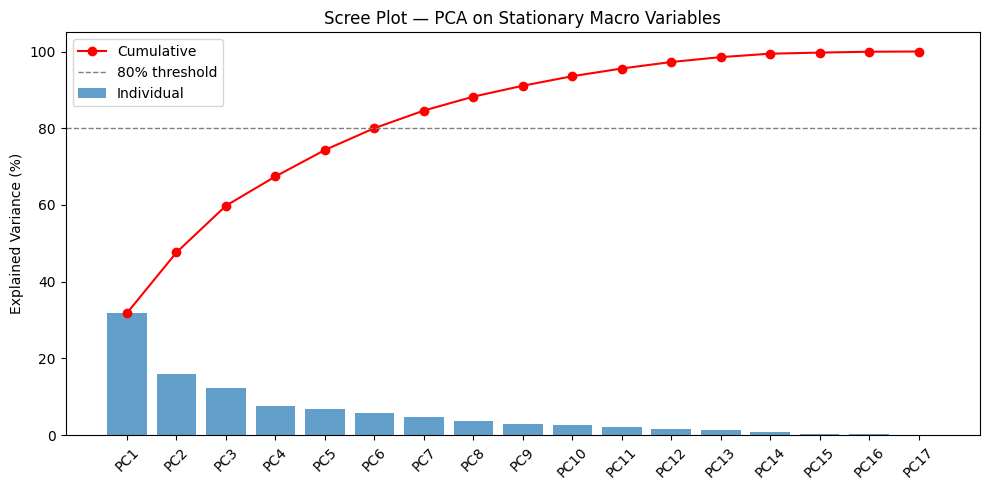

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- eigendecomposition directly on the correlation matrix ---
# (valid because corr matrix == cov matrix of standardized data)
eigvals, eigvecs = np.linalg.eigh(corr_matrix.values)

# eigh returns ascending order -> flip to descending (PC1 = most variance first)
eigvals = eigvals[::-1]
eigvecs = eigvecs[:, ::-1]

n_vars = corr_matrix.shape[0]
pc_names = [f'PC{i+1}' for i in range(n_vars)]

# --- explained variance ---
explained_var = eigvals / eigvals.sum()
cumulative_var = explained_var.cumsum()

variance_df = pd.DataFrame({
    'eigenvalue': eigvals,
    'explained_variance_%': explained_var * 100,
    'cumulative_%': cumulative_var * 100
}, index=pc_names)

print(variance_df.round(2))


# --- scree plot ---
plt.figure(figsize=(10, 5))
plt.bar(pc_names, explained_var * 100, alpha=0.7, label='Individual')
plt.plot(pc_names, cumulative_var * 100, color='red', marker='o', label='Cumulative')
plt.axhline(80, color='grey', linestyle='--', linewidth=1, label='80% threshold')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot — PCA on Stationary Macro Variables')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



Loadings for PC1–PC8:
                     PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
Continued_claims  -0.163 -0.379  0.252 -0.375  0.011 -0.222 -0.004 -0.256
Initial_claims    -0.328 -0.127  0.271 -0.322  0.036 -0.119  0.019 -0.180
Credit_spread     -0.201 -0.411 -0.155  0.284  0.040 -0.116 -0.104  0.323
NFCI              -0.145 -0.130 -0.140  0.465  0.219 -0.616 -0.080 -0.083
Slope             -0.060 -0.412 -0.019  0.070 -0.211  0.514 -0.091  0.271
CUMFNS             0.175  0.440 -0.012 -0.121  0.238 -0.069  0.110 -0.002
Log_CPI_diff       0.194  0.074  0.472  0.294 -0.047 -0.038  0.045 -0.108
Log_INDPRO_diff    0.354 -0.173 -0.029 -0.262  0.218 -0.031 -0.170 -0.006
TB3MS_diff         0.139  0.132  0.051 -0.174 -0.517 -0.364 -0.619  0.208
WTI_Returns        0.205 -0.124  0.420  0.128 -0.088 -0.146  0.135  0.199
TCU_diff           0.339 -0.216 -0.006 -0.253  0.177 -0.010 -0.224 -0.003
UNRATE_diff       -0.354  0.191  0.115  0.032 -0.198  0.082 -0.127 -0.162
UMCSENT_diff    

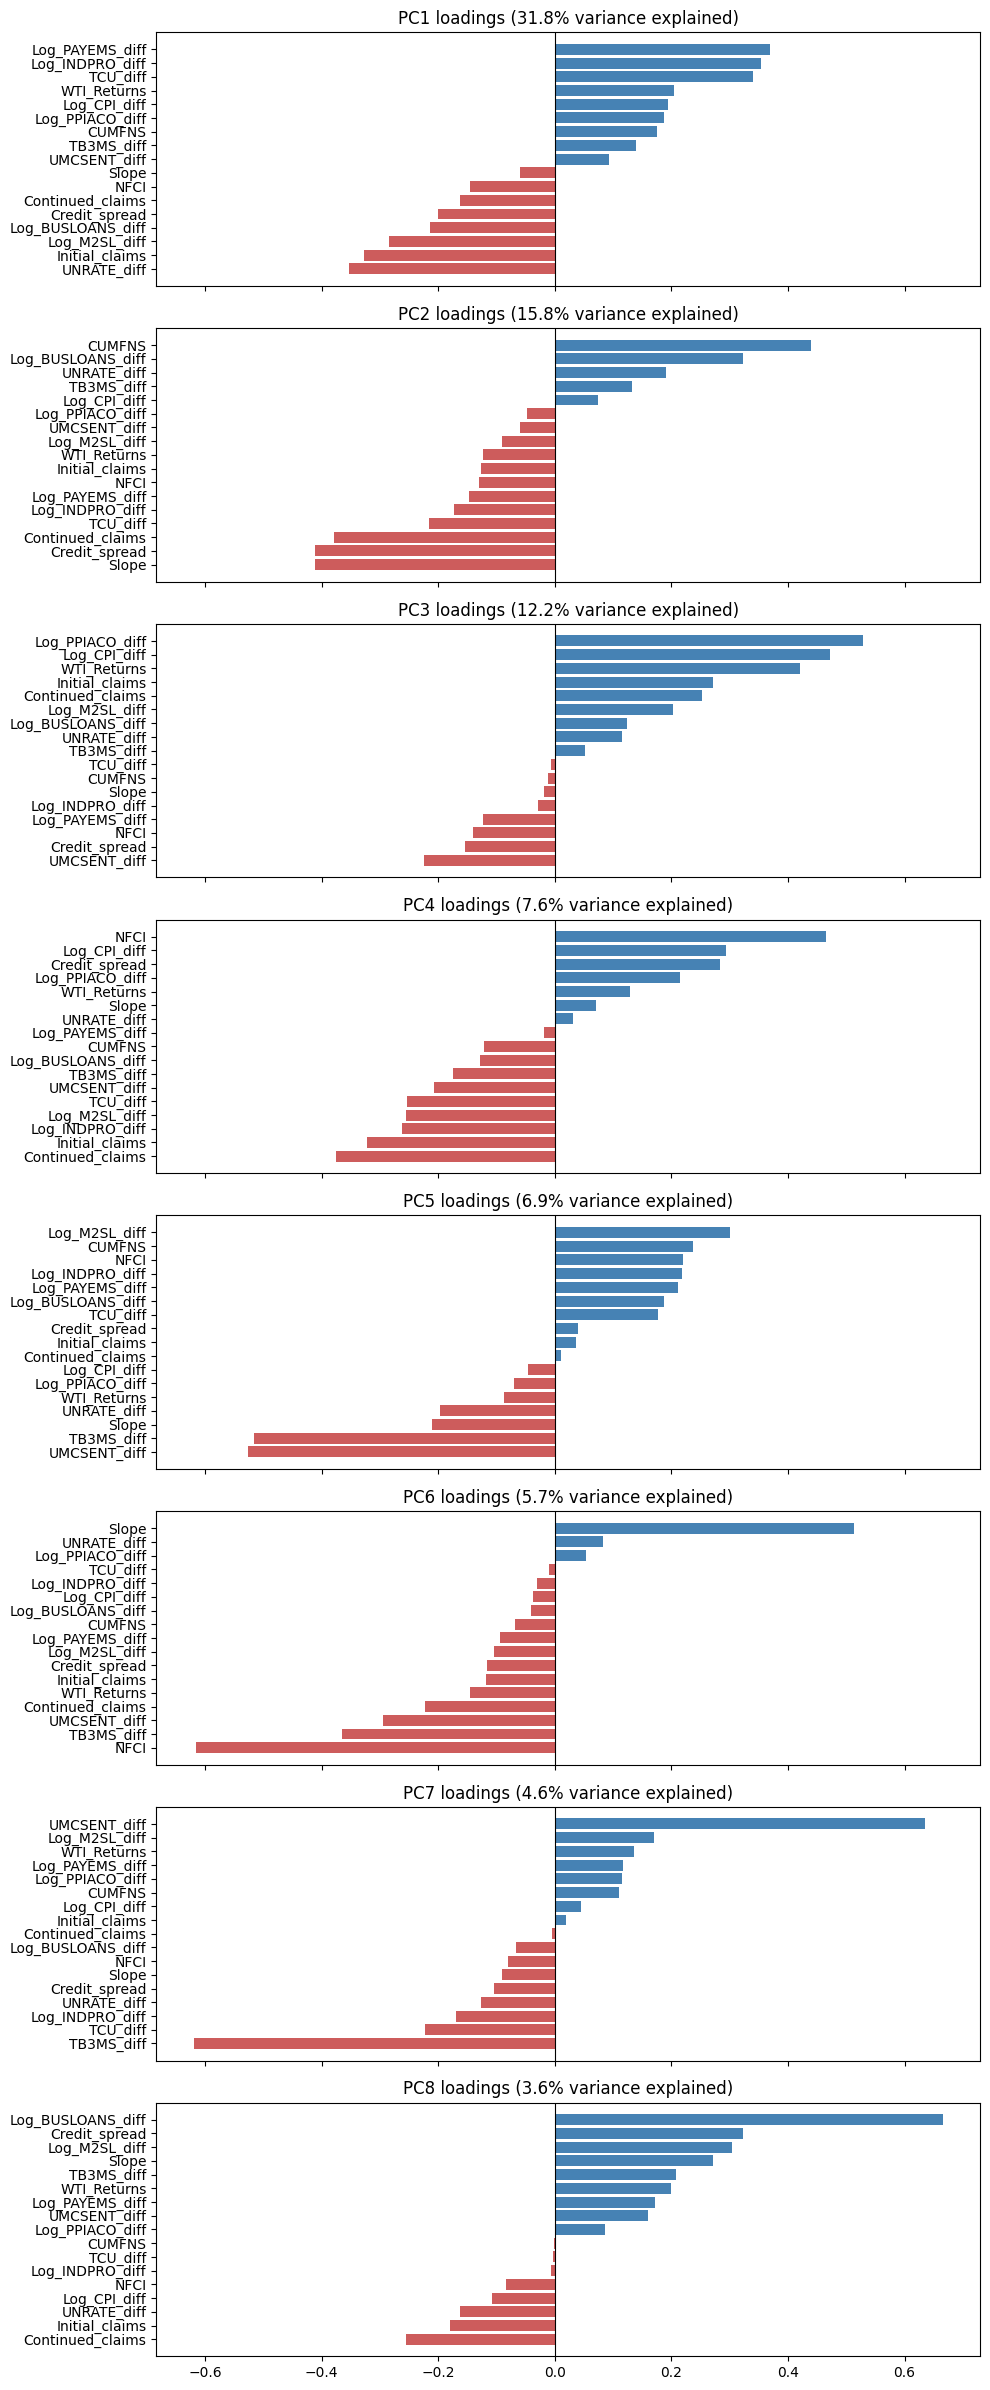


--- PC1 top loadings ---
Log_PAYEMS_diff    0.369
Log_INDPRO_diff    0.354
UNRATE_diff       -0.354
TCU_diff           0.339
Initial_claims    -0.328
Name: PC1, dtype: float64

--- PC2 top loadings ---
CUMFNS               0.440
Slope               -0.412
Credit_spread       -0.411
Continued_claims    -0.379
Log_BUSLOANS_diff    0.323
Name: PC2, dtype: float64

--- PC3 top loadings ---
Log_PPIACO_diff     0.530
Log_CPI_diff        0.472
WTI_Returns         0.420
Initial_claims      0.271
Continued_claims    0.252
Name: PC3, dtype: float64

--- PC4 top loadings ---
NFCI                0.465
Continued_claims   -0.375
Initial_claims     -0.322
Log_CPI_diff        0.294
Credit_spread       0.284
Name: PC4, dtype: float64

--- PC5 top loadings ---
UMCSENT_diff    -0.527
TB3MS_diff      -0.517
Log_M2SL_diff    0.301
CUMFNS           0.238
NFCI             0.219
Name: PC5, dtype: float64

--- PC6 top loadings ---
NFCI               -0.616
Slope               0.514
TB3MS_diff         -0.364
U

In [10]:
# --- loadings matrix: each column is a PC, each row is an original variable ---
loadings = pd.DataFrame(
    eigvecs,
    index=corr_matrix.columns,
    columns=pc_names
)

print("Loadings for PC1–PC8:")
print(loadings.iloc[:, :8].round(3))

# --- plot loadings for the first few components ---
# (only plot components worth keeping — adjust n_components_to_plot once you see the scree plot)
n_components_to_plot = 8

fig, axes = plt.subplots(n_components_to_plot, 1, figsize=(10, 3*n_components_to_plot), sharex=True)

for i in range(n_components_to_plot):
    pc = f'PC{i+1}'
    vals = loadings[pc].sort_values()
    colors = ['steelblue' if v >= 0 else 'indianred' for v in vals]
    axes[i].barh(vals.index, vals.values, color=colors)
    axes[i].set_title(f'{pc} loadings ({explained_var[i]*100:.1f}% variance explained)')
    axes[i].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# --- quick check: which variables load most heavily on each PC (top 5 by |loading|) ---
for i in range(n_components_to_plot):
    pc = f'PC{i+1}'
    top5 = loadings[pc].sort_values(key=abs, ascending=False).head(5)
    print(f"\n--- {pc} top loadings ---")
    print(top5.round(3))

# Findings:

PC1 - PC6 captures 80.01% of the variance.

Before deciding, analyse the PC's to determine if each represent an "economic story". Check top loadings above.
Recall we don't need to explain clear correlations, as the PCs aim to capture empirical evidence from the data.
PC1 -PC4 clear stories:

PC1 - Strength of the economy/business cycle 
        Non-farm payroll, production, cap utilisation ect. Classic steady growth indicator. The negative commercial industrial loans and M2 money supply is likely due to the emergency response during crashes so will be interesting to reevaluate excluding COVID.

PC2 - Credit and Capacity conditions
        Adressing whether we are in the capacity-constrained part of expansion i.e. late expansion. We've had steady growth but CB begins to raise rates (i.e. yield curve flattening). Turning point coming

PC3 - Inflation pressure
        Producer/consumer prices and energy prices. 

PC4 - Financial Stress with no labour market deterioration yet
        NFCI (+0.465), Continued_claims (-0.375), Initial_claims (-0.322), Log_CPI_diff (+0.294), Credit_spread (+0.284)

        

PC5 - Policy rate vs. Consumer Sentiment
        UMCSENT_diff (-0.527), TB3MS_diff (-0.517), Log_M2SL_diff (+0.301) Sentiment tends to move with short term rates, reflects start of easing cycle: money supply up, rates down, sentiment hasnt recovered yet.
PC6 - Yield Curve & rates
        Slope (+0.514), TB3MS_diff (-0.364), UMCSENT_diff (-0.295), NFCI (-0.616) easing financial conditions, 10Y - 2Y increasing, still see short term rates and sentiment decrease as they tend to. Reflects returning back to normality post crisis, or active easing.
PC7 - Confidence during easing
        UMCSENT_diff (+0.634), TB3MS_diff (-0.619), short-term extreme confidence during rate cuts
PC8 - Log_BUSLOANS_diff 
        Mainly Log_BUSLOANS_diff, likely due to COVID emergency response. CAREFUL!

PC1 - PC7 have logical themes, however PC8 is definitely to drop and dependent on COVID


